In [1]:
#Version Numbers Used to Generate this Pset:
#seaborn=0.11.2
#scipy==1.8.0
#numpy==1.22.2
#matplotlib==3.5.1

import scipy as sp
from pylab import *
import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.ticker import MultipleLocator,FormatStrFormatter,MaxNLocator
import pandas as pd
import seaborn as sns
import collections
from IPython.display import clear_output
import random
import openpyxl
import os 
sns.set_style("ticks")
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, explained_variance_score, r2_score
from sklearn.preprocessing import PolynomialFeatures
import pickle
from matplotlib.colors import LogNorm  # Import LogNorm for logarithmic color scale

DataTitle="Data_dynamics"

np.random.seed(1)
if not os.path.exists(DataTitle):

   # Create a new directory because it does not exist
   os.makedirs(DataTitle)
   print("The new directory is created!")

mm = 0.1/2.54
os.environ['PATH'] = os.environ['PATH'] + ':/Library/TeX/texbin/latex'
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['figure.dpi'] = 600
mpl.rcParams['font.size'] = 8
mpl.rcParams['axes.linewidth'] = 0.5
mpl.rcParams['xtick.minor.width'] = 0.4
mpl.rcParams['xtick.major.width'] = 0.5
mpl.rcParams['ytick.minor.width'] = 0.4
mpl.rcParams['ytick.major.width'] = 0.5

plt.rcParams['text.usetex'] = False
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

sns.color_palette("tab10")

[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (1.0, 0.4980392156862745, 0.054901960784313725),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
 (0.4980392156862745, 0.4980392156862745, 0.4980392156862745),
 (0.7372549019607844, 0.7411764705882353, 0.13333333333333333),
 (0.09019607843137255, 0.7450980392156863, 0.8117647058823529)]

In [2]:
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

my_cmap = ListedColormap(['#00429d', '#4771b2', '#73a2c6', '#a5d5d8', '#ffffe0', '#ffbcaf', '#f4777f', '#cf3759', '#93003a'], name="my_cmap")
my_cmap_r = my_cmap.reversed()
mpl.colormaps.register(cmap=my_cmap)
mpl.colormaps.register(cmap=my_cmap_r)

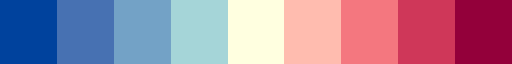

In [3]:
my_cmap

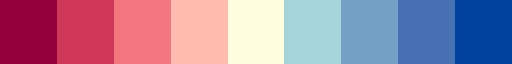

In [4]:
my_cmap_r

In [5]:
def getIDX(data, IDX):
    O = np.flatnonzero([x == IDX for x in data['SampleIDX']])
    return np.array(O)

def getAbundance(Processed_sequences,IDX):
    SampleIdx= np.flatnonzero([x == IDX for x in Processed_sequences['SampleIDX']])
    if not any(SampleIdx):
        return
    else:
        O=Processed_sequences.iloc[SampleIdx].values.tolist()[0][1:]
        return O

def getAbundance_fromList(Processed_sequences,IDX_list):
    IDX_list_=np.squeeze([np.where(Processed_sequences['SampleIDX']==x) for x in IDX_list])
    return (np.array(Processed_sequences.iloc[IDX_list_].values)[:,1:]).astype(float)

def Community_PermutateList_simulation(I,S):
    global Metadata,exception_list
    sample_num=100
    O=(3*(I-1)+(S-1))*100+np.arange(0,100)
    return O

def CommunityPermutate(Timepoint, CommunityOrigin, Medium, CoalescenceType):
    global Metadata
    idx = np.where((Metadata['Timepoint'] == Timepoint) &
                   (Metadata['CommunityOrigin'] == CommunityOrigin) &
                   (Metadata['Medium'] == Medium) &
                   (Metadata['CoalescenceType'] == CoalescenceType))[0]
    O = np.concatenate(Metadata['SampleIDX'][idx])
    return O

def CommunityPermutate_withSpeciesPoolsize(Timepoint, CommunityOrigin, Medium, CoalescenceType, species_pool_num):
    global Metadata,exception_list
    idx = (Metadata['Timepoint'] == Timepoint) & \
          (Metadata['CommunityOrigin'] == CommunityOrigin) & \
          (Metadata['Medium'] == Medium) & \
          (Metadata['CoalescenceType'] == CoalescenceType)

    communityIDX = np.array([int(x) for x in Metadata['CommunityIDX']])
    if CoalescenceType == 'S':
        if species_pool_num == 6:
            idx = idx & (communityIDX <= 9)
        elif species_pool_num == 12:
            idx = idx & ((communityIDX > 9) & (communityIDX <= 18))
        elif species_pool_num == 24:
            idx = idx & ((communityIDX > 18) & (communityIDX <= 30))
    elif CoalescenceType == 'C':
        if species_pool_num == 6:
            idx = idx & (communityIDX <= 14)
        elif species_pool_num == 12:
            idx = idx & ((communityIDX > 14) & (communityIDX <= 41))
        elif species_pool_num == 24:
            idx = idx & ((communityIDX > 41) & (communityIDX <= 47))

    O = Metadata['SampleIDX'][idx]
    O = list(set(O) - set(exception_list))
    return O

def Community_PermutateList(Timepoint, CommunityOrigin, Medium, CoalescenceType, species_pool_num=0, Replicate=-1):
    global Metadata,exception_list
    
    if Replicate==-1:
        idx = (Metadata['Timepoint'] == Timepoint) & \
              (Metadata['CommunityOrigin'] == CommunityOrigin) & \
              (Metadata['Medium'] == Medium) & \
              (Metadata['CoalescenceType'] == CoalescenceType)
    elif Replicate == 1 or Replicate == 2 : 
        idx = (Metadata['Timepoint'] == Timepoint) & \
              (Metadata['CommunityOrigin'] == CommunityOrigin) & \
              (Metadata['Medium'] == Medium) & \
              (Metadata['CoalescenceType'] == CoalescenceType) & \
              (Metadata['Replicate'] == Replicate)
    else : 
        raise ValueError("Invalid input")

    
    if CommunityOrigin=='S':
        communityIDX = np.array([int(x) for x in Metadata['CommunityIDX']])
        if CoalescenceType == 'S':
            if species_pool_num == 6:
                idx = idx & (communityIDX <= 9)
            elif species_pool_num == 12:
                idx = idx & ((communityIDX > 9) & (communityIDX <= 18))
            elif species_pool_num == 24:
                idx = idx & ((communityIDX > 18) & (communityIDX <= 30))
            elif species_pool_num ==0:
                idx = idx
        elif CoalescenceType == 'C':
            if species_pool_num == 6:
                idx = idx & (communityIDX <= 14)
            elif species_pool_num == 12:
                idx = idx & ((communityIDX > 14) & (communityIDX <= 41))
            elif species_pool_num == 24:
                idx = idx & ((communityIDX > 41) & (communityIDX <= 47))
            elif species_pool_num ==0:
                idx = idx
    elif CommunityOrigin=='N':
        communityIDX = np.array([int(x) for x in Metadata['CommunityIDX']])
        
    O = Metadata['SampleIDX'][idx]
    O = list(set(O) - set(exception_list))
    return O

def getCommunities(Communities_data,IDX_list):
    IDX_list_=np.squeeze([np.where(Communities_data['SampleIDX']==x) for x in IDX_list])
    return (Communities_data.iloc[IDX_list_])

def getCoalescence(Coalescence_data,IDX_list):
    IDX_list_=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])#IDX_list_
    return (Coalescence_data.iloc[IDX_list_])

Coalescence_data_synthetic_path ="../../Analyzed/processed_CoalescenceEvent_synthetic.xlsx"
Communities_data_synthetic_path ="../../Analyzed/processed_Communities_synthetic.xlsx"
Coalescence_data_natural_path ="../../Analyzed/processed_CoalescenceEvent_natural.xlsx"
Communities_data_natural_path ="../../Analyzed/processed_Communities_natural.xlsx"
Coalescence_recipe_path="../../Postprocessed/CoalescenceRecipe.xlsx"
Meta_data_path="../../Postprocessed/Metadata.xlsx"
Processed_sequences_synthetic_path="../../Postprocessed/processed_Sequences_synthetic.xlsx"
Processed_sequences_natural_path="../../Postprocessed/processed_Sequences_natural.xlsx"
Coalescence_data_sim_path="../../Analyzed/processed_CoalescenceEvent_simulation_uniform.xlsx"
#Communities_data_sim_path="Analyzed/processed_Communities_simulation_uniform.xlsx"

Coalescence_data=pd.concat([pd.read_excel(Coalescence_data_synthetic_path),pd.read_excel(Coalescence_data_natural_path)])
Communities_data=pd.concat([pd.read_excel(Communities_data_synthetic_path),pd.read_excel(Communities_data_natural_path)])
Coalescence_data_sim=pd.read_excel(Coalescence_data_sim_path)
#Communities_data_sim=pd.read_excel(Communities_data_sim_path)

Coalescence_recipe=pd.read_excel(Coalescence_recipe_path,sheet_name=0)
Coalescence_natural_recipe=pd.read_excel(Coalescence_recipe_path,sheet_name=1)
Metadata=pd.read_excel(Meta_data_path)
Processed_sequences_synthetic=pd.read_excel(Processed_sequences_synthetic_path)
Processed_sequences_natural=pd.read_excel(Processed_sequences_natural_path)

exception_list=['P4-02','P4-03','P4-23','P4-24','P7-97', 'P8-12']+['P8-91'] + ['P5-73', 'P5-69','P5-64','P5-61','P5-59', 'P5-56'] + ['P5-47', 'P5-50'] + ['P5-39', 'P5-87', 'P5-54', 'P6-02', 'P6-47', 'P6-74', 'P6-57']
#'P4-02','P4-03','P4-23','P4-24','P7-97', 'P8-12' : These cases are for no reads in coalescence result
# 'P8-91' : no file
#['P5-73', 'P5-69','P5-64','P5-61','P5-59', 'P5-56'] : MN E7 is missing
# 'P6-67' : is too low reads( 500)
# 'P5-47', 'P5-50' : MN24 CC, too much unwanted ASVs(maybe due to wrong labeling)
# ['P5-39', 'P5-87', 'P5-54', 'P6-02', 'P6-47', 'P6-74', 'P6-57'] : ASV not in sub 2> 0.3

I = [0.33, 0.66, 0.99]
species_pools = [6, 12, 24]
sample_num=100
Syn_Simulation_IDX = {
    "I1_S1": Community_PermutateList_simulation(1,1),
    "I1_S2": Community_PermutateList_simulation(1,2),
    "I1_S3": Community_PermutateList_simulation(1,3),
    "I2_S1": Community_PermutateList_simulation(2,1),
    "I2_S2": Community_PermutateList_simulation(2,2),
    "I2_S3": Community_PermutateList_simulation(2,3),
    "I3_S1": Community_PermutateList_simulation(3,1),
    "I3_S2": Community_PermutateList_simulation(3,2),
    "I3_S3": Community_PermutateList_simulation(3,3),
}
mediums_pools = ["LN", "MN", "HN"]
species_pools = [6, 12, 24]
Syn_Coal_IDX = {
    "LN_6": Community_PermutateList("F", "S", "L", "C", 6),
    "LN_12": Community_PermutateList("F", "S", "L", "C", 12),
    "LN_24": Community_PermutateList("F", "S", "L", "C", 24),
    "MN_6": Community_PermutateList("F", "S", "M", "C", 6),
    "MN_12": Community_PermutateList("F", "S", "M", "C", 12),
    "MN_24": Community_PermutateList("F", "S", "M", "C", 24),
    "HN_6": Community_PermutateList("F", "S", "H", "C", 6),
    "HN_12": Community_PermutateList("F", "S", "H", "C", 12),
    "HN_24": Community_PermutateList("F", "S", "H", "C", 24)
}
Syn_Sub_IDX = {
    "LN_6": Community_PermutateList("F", "S", "L", "S", 6),
    "LN_12": Community_PermutateList("F", "S", "L", "S", 12),
    "LN_24": Community_PermutateList("F", "S", "L", "S", 24),
    "MN_6": Community_PermutateList("F", "S", "M", "S", 6),
    "MN_12": Community_PermutateList("F", "S", "M", "S", 12),
    "MN_24": Community_PermutateList("F", "S", "M", "S", 24),
    "HN_6": Community_PermutateList("F", "S", "H", "S", 6),
    "HN_12": Community_PermutateList("F", "S", "H", "S", 12),
    "HN_24": Community_PermutateList("F", "S", "H", "S", 24)
}
Nat_Coal_IDX = {
    "LN": Community_PermutateList("F", "N", "L", "C"),
    "MN": Community_PermutateList("F", "N", "M", "C"),
    "HN": Community_PermutateList("F", "N", "H", "C")
}
Nat_Sub_IDX = {
    "LN": Community_PermutateList("F", "N", "L", "S"),
    "MN": Community_PermutateList("F", "N", "M", "S"),
    "HN": Community_PermutateList("F", "N", "H", "S")
}




In [6]:
from InitializeSpeciesPool import *
from LV import *
from VariousMetrics import *

########################################################
########################################################
# Fig 3-1
########################################################
########################################################

##~~~~~~~~~~~~~~ This figure is cartoon ~~~~~~~~~~~~~~##

In [7]:
min(0.5,0.1)

0.1

In [9]:
def pHcriteria(pH_list,return_type="Num"):
    pH_list=np.array(pH_list)
    O=1*(pH_list>6)+1*(pH_list>8)
    if return_type=="Num":
        return O
    if return_type=="Word":
        word_list=['acidic','neutral','alkalic']
        return [word_list[x] for x in O]
    if return_type=="Color":
        word_list=['r','g','b']
        return [word_list[x] for x in O]

def getDominanceMatrix(Variable2plot, Coalescence_data, Coal_IDX_list, Sub_IDX_list):
    N=len(Sub_IDX_list)
    matrix={Sub_IDX : {} for Sub_IDX in Sub_IDX_list }
    for SampleIDX in Coal_IDX_list:
        idx=np.where(Coalescence_data['SampleIDX']==SampleIDX)
        dominance1=Coalescence_data.iloc[idx][Variable2plot].tolist()[0]
        dominance2=1-dominance1
        subSampleIDX1=Coalescence_data.iloc[idx]["SampleIDX_Sub1"].tolist()[0]
        #subidx1=np.where(Sub_IDX_list==subSmapleIDX1)
        subSampleIDX2=Coalescence_data.iloc[idx]["SampleIDX_Sub2"].tolist()[0]


        #subidx2=np.where(Sub_IDX_list==subSmapleIDX2)
        matrix[subSampleIDX1].update({subSampleIDX2:dominance1})
        matrix[subSampleIDX2].update({subSampleIDX1:dominance2})
    for SampleIDX in Sub_IDX_list:
        matrix[SampleIDX].update({SampleIDX:0.5})
    
    return matrix   

def EstimateErrorLassoRegression(IDX_list, x, y, order, alpha, beta, preprocess='Basic', verbose=False):
    communityIDX_list=np.unique(getCommunities(Communities_data,IDX_list)['CommunityIDX'])
    train_mse_list=[]
    test_mse_list=[]
    
    if preprocess=='Basic':
        y_tofit=y.copy()
    elif preprocess=='Normalize':
        y_tofit=(y.copy()-0.5)*2
    elif preprocess=='Tan':
        y_tofit=np.tan((y.copy()-0.5)*np.pi/2)
    
    fig=plt.figure(figsize=(70*mm,60*mm))

    for communityID_toTest in communityIDX_list:  
        getCommunities(Communities_data,Community_PermutateList("F", com_type, medium, "S", species_num, rep))
        train_idx_list=np.where(getCommunities(Communities_data,IDX_list)['CommunityIDX']!=communityID_toTest)[0]
        test_idx_list=np.where(getCommunities(Communities_data,IDX_list)['CommunityIDX']==communityID_toTest)[0]

        # Generate synthetic data
        X_train = beta*x[train_idx_list,:]
        y_train = y_tofit[train_idx_list]#y[:]
        X_test = beta*x[test_idx_list,:]
        y_test = y_tofit[test_idx_list]
        # Split data into training and testing sets
        
        # Transform features to include up to second-order terms
        polynomial_features = PolynomialFeatures(degree=order, include_bias=True)
        X_train_poly = polynomial_features.fit_transform(X_train)
        X_test_poly = polynomial_features.transform(X_test)

        # Create the model
        model = Lasso(alpha=alpha, max_iter = 1000)

        # Fit the model to the training data
        model.fit(X_train_poly, y_train)

        # Predict the target values for the test set
        y_pred_train = model.predict(X_train_poly)
        y_pred_test = model.predict(X_test_poly)

        # Evaluate the model
        train_mse = np.mean((y_train-y_pred_train)**2)
        test_mse = np.mean((y_test-y_pred_test)**2)
        ref_mse= np.var(y_tofit)
        if verbose:
            print(f'Mean Train Squared Error: {train_mse}')
            print(f'Mean Test Squared Error: {test_mse, y_test, y_pred_test}')
        plt.scatter(y_test,y_pred_test)
        train_mse_list.append(train_mse/ref_mse)
        test_mse_list.append(test_mse/ref_mse)
    
    range_min=min(plt.xlim()[0],plt.ylim()[0])
    range_max=max(plt.xlim()[1],plt.ylim()[1])
    plt.plot([range_min, range_max],  [range_min,range_max], color='r')
    print([range_min, range_max],  [range_min,range_max])
    plt.text(range_max, range_max, f'Error={mean(test_mse_list)}',color='r', fontsize=6)
    if True:
        getCommunities(Communities_data,Community_PermutateList("F", com_type, medium, "S", species_num, rep))
        train_idx_list=np.where(getCommunities(Communities_data,IDX_list)['CommunityIDX'])[0]
        test_idx_list=[]

        # Generate synthetic data
        X_train = beta*x[train_idx_list,:]
        y_train = y_tofit[train_idx_list]#y[:]
        X_test = beta*x[test_idx_list,:]
        y_test = y_tofit[test_idx_list]
        # Split data into training and testing sets
        
        # Transform features to include up to second-order terms
        polynomial_features = PolynomialFeatures(degree=order, include_bias=True)
        X_train_poly = polynomial_features.fit_transform(X_train)
        #X_test_poly = polynomial_features.transform(X_test)

        # Create the model
        model = Lasso(alpha=alpha, max_iter = 1000)

        # Fit the model to the training data
        model.fit(X_train_poly, y_train)

        
    return communityIDX_list, train_mse_list, test_mse_list ,model, polynomial_features
    

In [15]:
df_sorted

,P2-31,P2-43,P2-37,P2-25,P2-30,P2-29,P2-41,P2-39,P2-40,P2-27,P2-42,P2-28,P2-44,P2-38,P2-26,P2-45,P2-33,P2-32
P2-31,0.500000,NaN,NaN,NaN,0.210313,0.175998,NaN,NaN,NaN,0.062442,NaN,0.286795,NaN,NaN,0.000000,NaN,NaN,0.068454
P2-43,NaN,0.500000,NaN,NaN,NaN,NaN,0.106710,0.014474,0.426504,NaN,0.135083,NaN,0.253210,0.003595,NaN,NaN,NaN,NaN
P2-37,NaN,NaN,0.500000,NaN,NaN,NaN,0.222593,0.054648,0.444065,NaN,0.222512,NaN,0.440514,NaN,NaN,0.030760,NaN,NaN
P2-25,NaN,NaN,NaN,0.500000,0.447812,0.203630,NaN,NaN,NaN,0.245701,NaN,0.221571,NaN,NaN,NaN,NaN,0.240948,0.147922
P2-30,0.789687,NaN,NaN,0.552188,0.500000,NaN,NaN,NaN,NaN,NaN,NaN,0.105843,NaN,NaN,0.003136,NaN,0.109436,0.004337
P2-29,0.824002,NaN,NaN,0.796370,NaN,0.500000,NaN,NaN,NaN,0.061829,NaN,0.151167,NaN,NaN,0.006029,NaN,0.118888,NaN
P2-41,NaN,0.893290,0.777407,NaN,NaN,NaN,0.500000,0.243670,0.032520,NaN,NaN,NaN,NaN,0.026430,NaN,0.054458,NaN,NaN
P2-39,NaN,0.985526,0.945352,NaN,NaN,NaN,0.756330,0.500000,NaN,NaN,NaN,NaN,0.069026,0.210249,NaN,0.008746,NaN,NaN
P2-40,NaN,0.573496,0.555935,NaN,NaN,NaN,0.967480,NaN,0.500000,NaN,0.970141,NaN,0.042848,NaN,NaN,0.003875,NaN,NaN
P2-27,0.937558,NaN,NaN,0.754299,NaN,0.938171,NaN,NaN,NaN,0.500000,NaN,NaN,NaN,NaN,0.151748,NaN,0.022173,0.326038


In [13]:
np.array(competitive_scores)-0.5

array([ 0.21320244, -0.23840751, -0.01856955, -0.05646661,  0.14881647,
        0.20505321,  0.31371402, -0.30800956, -0.25933291,  0.22641547,
       -0.22815943,  0.0035386 , -0.01625345,  0.13888944, -0.03007297,
        0.29434623, -0.21353059, -0.25241976])

In [16]:
Sub_IDX_list=Community_PermutateList("F", com_type, medium, "S", species_num, rep)
len(list(Sub_IDX_list))

18

[-0.6781914779653703, 0.6896003916511094] [-0.6781914779653703, 0.6896003916511094]


ValueError: too many values to unpack (expected 3)

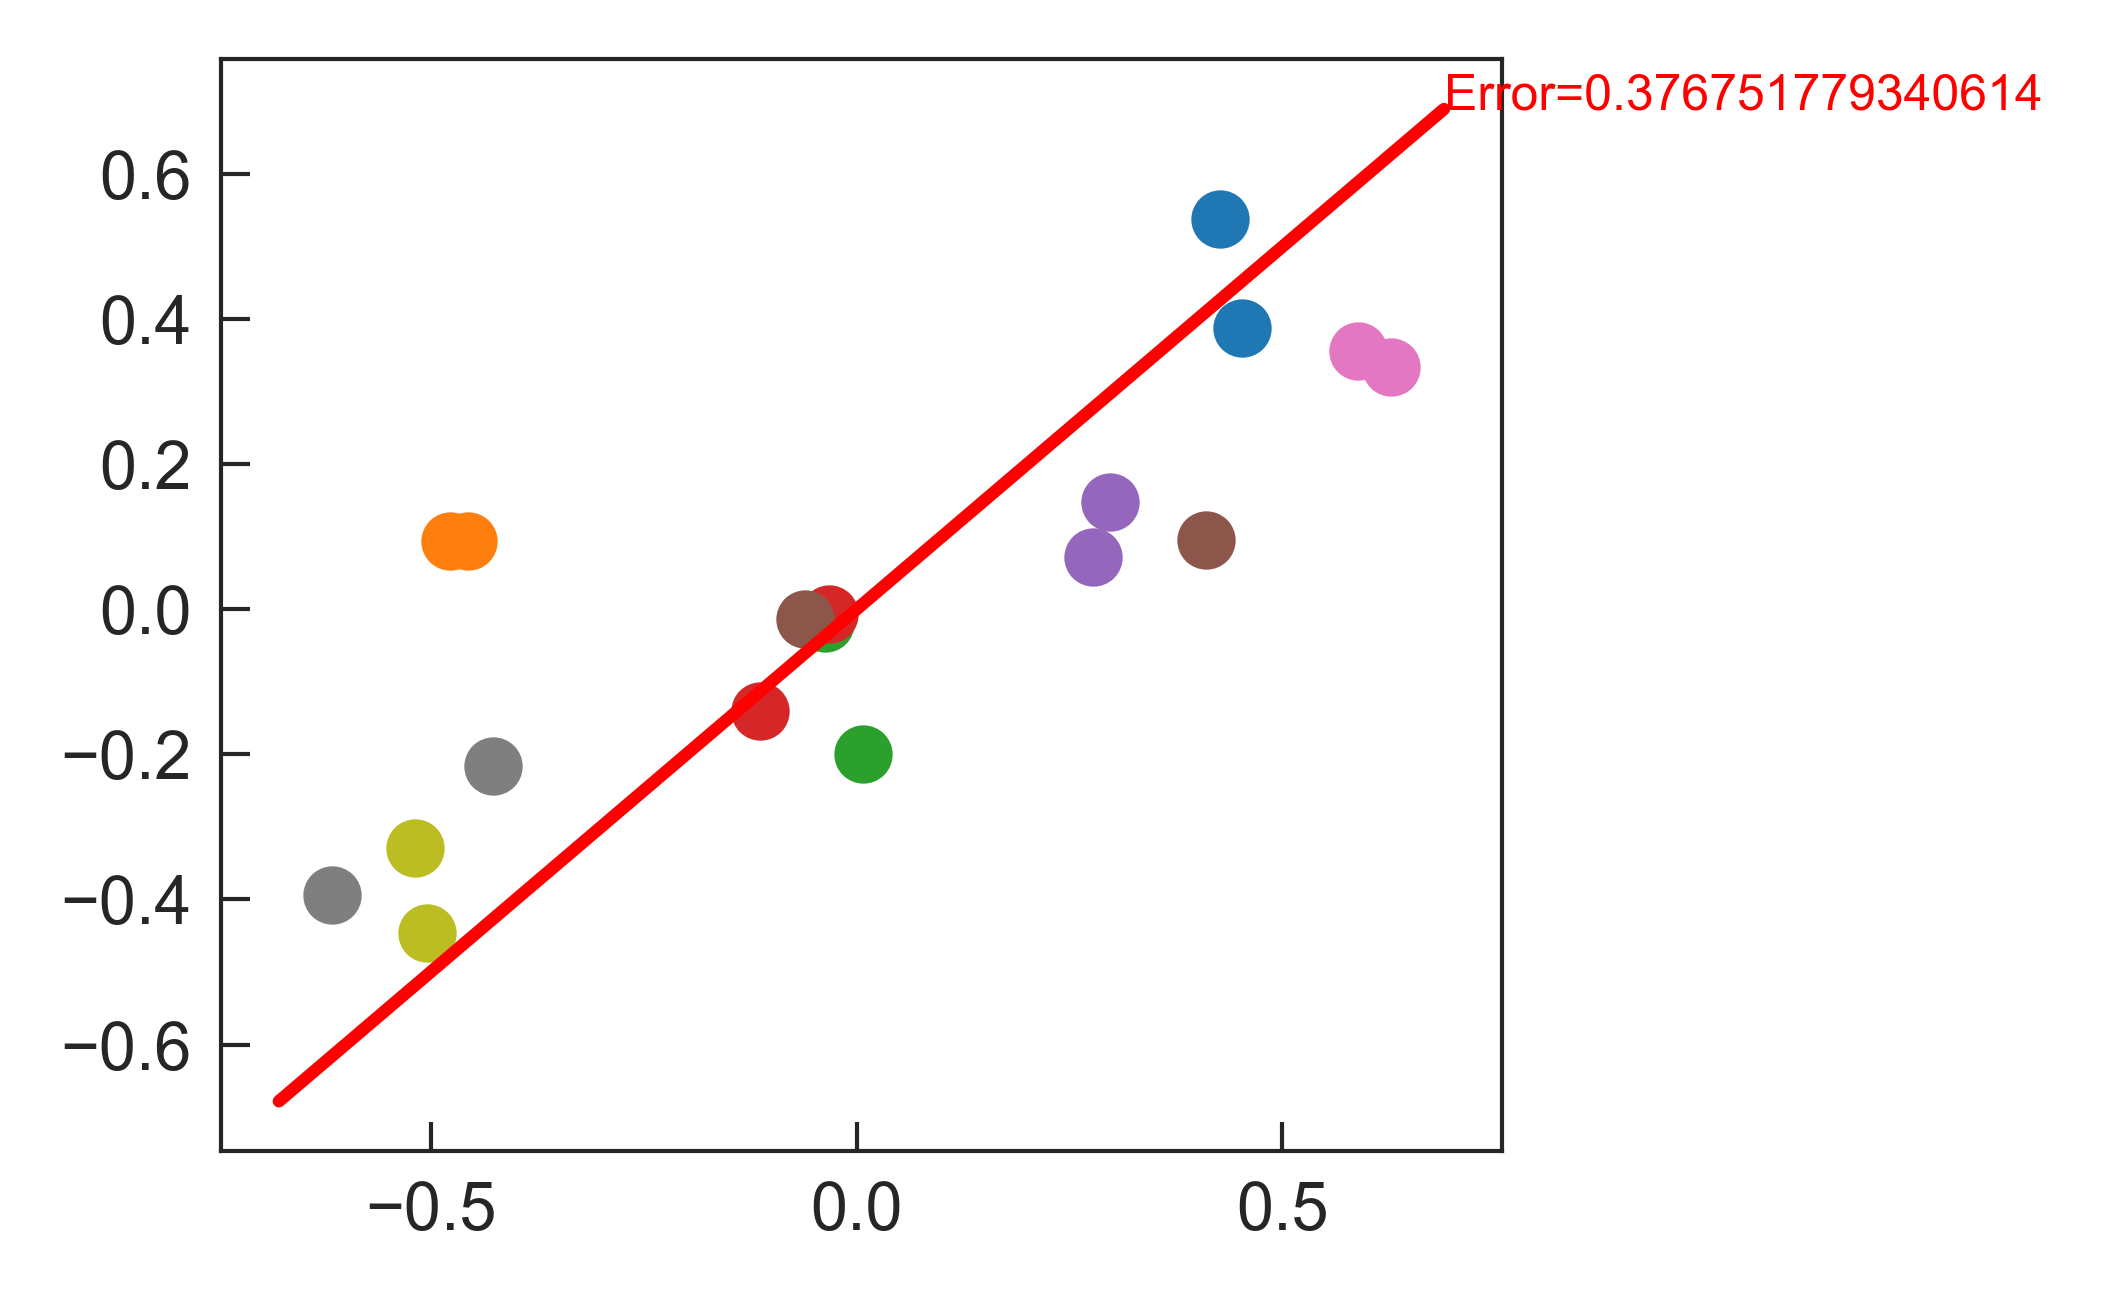

In [10]:
## First choice : Include certain species number only

# Set community Variable
Variable2plot='SimilarityTo1_BC_5'
medium="H"
species_num=12
com_type="S"
rep=-1

# Set Hyper parameter Variable
alphas=np.logspace(-5, -0, num=50)
betas=np.logspace(-3, 3, num=60)
order=1
preprocess='Normalize' ##'Basic', 'Normalize', 'ArcTanh'


##
Sub_IDX_list=Community_PermutateList("F", com_type, medium, "S", species_num, rep)
Coal_IDX_list=Community_PermutateList("F", com_type, medium, "C", species_num, rep)

matrix=getDominanceMatrix(Variable2plot, Coalescence_data, Coal_IDX_list, Sub_IDX_list)
df = pd.DataFrame(matrix)
df_sorted=df.sort_index(axis=1)
df_sorted=df_sorted.sort_index(axis=0)
competitive_scores = [1-np.mean(df.loc[row_col,:]) for row_col in df_sorted.index]

# Sort rows and columns by competitive score
sorted_idx = np.argsort(competitive_scores)[::-1]
df_sorted = df_sorted.iloc[sorted_idx, sorted_idx]
competitive_scores_sorted = [1-np.mean(df_sorted.loc[row_col,:]) for row_col in df_sorted.index]
competitive_scores_sorted

#getAbundance(getIDX(Processed_sequences_synthetic, IDX))
IDX_list=df_sorted.keys()
x=np.array(getAbundance_fromList(Processed_sequences_synthetic,df_sorted.keys()))
y=np.array(competitive_scores_sorted)

mean_train_mse={}
mean_test_mse={}
for alpha in alphas:
    for beta in betas:
        communityIDX_list, train_mse_list, test_mse_list = EstimateErrorLassoRegression(IDX_list, x, y, order=order, alpha=alpha, beta=beta, preprocess=preprocess)        
        mean_train_mse[(alpha, beta)] = np.mean(train_mse_list)
        mean_test_mse[(alpha, beta)] = np.mean(test_mse_list)
        print(f"Processing for alpha = {alpha} and beta = {beta} is done. Result: {np.mean(train_mse_list),  np.mean(test_mse_list)}")

TrialTitle=f"Partial_SpeciesNum_{species_num}_Medium_{medium}_Order_{order}_Preprocess_{preprocess}"
with open('Data/'+TrialTitle+'_mean_train_mse.pkl', 'wb') as f:
    pickle.dump(mean_train_mse, f)

with open('Data/'+TrialTitle+'_mean_test_mse.pkl', 'wb') as f:
    pickle.dump(mean_test_mse, f)
                                                
# To load the pickled data back
with open('Data/'+TrialTitle+'_mean_test_mse.pkl', 'rb') as f:
    loaded_results = pickle.load(f)
    
print(loaded_results)

0.6250551925273976 153.61749466718297


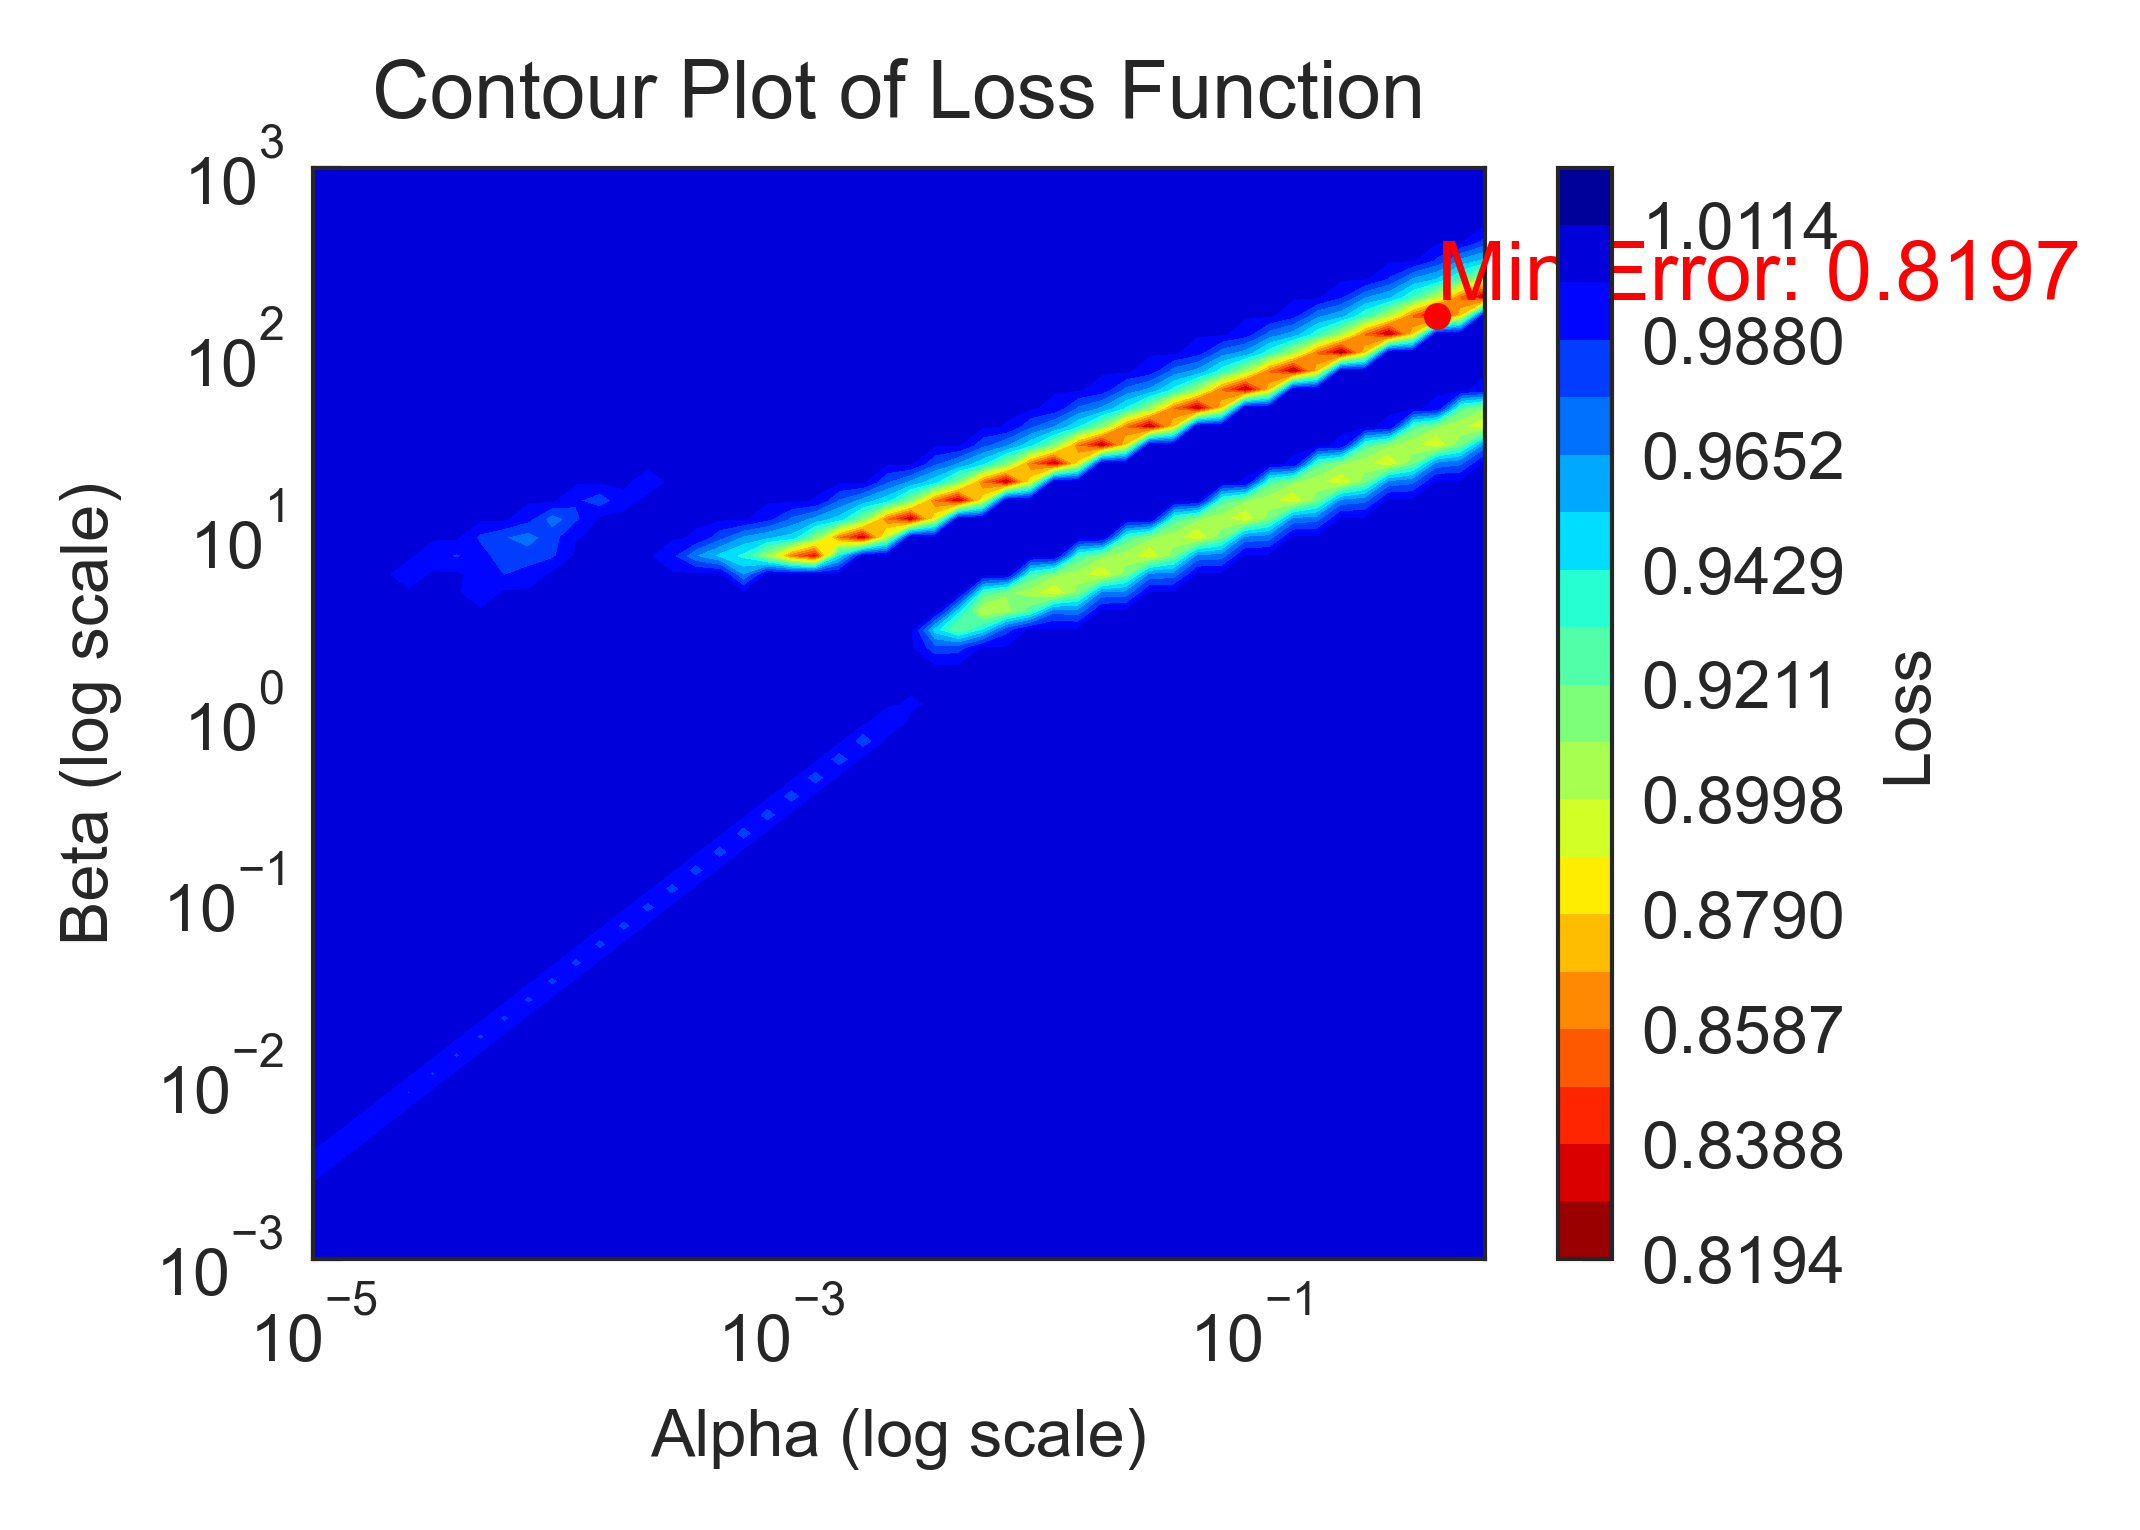

In [ ]:

filename='Partial_SpeciesNum_12_Medium_M_Order_2_Preprocess_Normalize_mean_test_mse'
with open('Data/'+filename+'.pkl', 'rb') as f:
    loaded_results = pickle.load(f)
    
# Create a grid of alpha and beta values
alpha_grid, beta_grid = np.meshgrid(alphas, betas)

loss_values=np.zeros([len(alphas), len(betas)])

for i, alpha in enumerate(alphas):
    for j, beta in enumerate(betas):
        loss_values[i,j]=loaded_results[(alpha,beta)]


centered_offset=1
loss_values_centered=loss_values[centered_offset:-centered_offset,centered_offset:-centered_offset]
min_indices = np.unravel_index(np.argmin(loss_values_centered), loss_values_centered.shape)
global_min_alpha = alphas[centered_offset+min_indices[0]]
global_min_beta = betas[centered_offset+min_indices[1]]
global_min_loss = loss_values_centered[min_indices]

print(global_min_alpha,global_min_beta)

levels = np.logspace(np.log10(np.min(loss_values)), 0.01, 20)

# Create a contour plot
plt.figure(figsize=(80*mm,60*mm))
contour = plt.contourf(alpha_grid, beta_grid, np.minimum(loss_values.T,1.001), levels=levels, cmap='jet_r', norm=LogNorm())
plt.scatter(global_min_alpha, global_min_beta, color='red', marker='.', s=20)
plt.text(global_min_alpha+2e-5, global_min_beta+2e-5, f'Min Error: {global_min_loss:.4f}', color='red', fontsize=10, ha='left', va='bottom')

plt.colorbar(contour, label='Loss')
plt.xscale('log')  # Set x-axis to log scale
plt.yscale('log')  # Set y-axis to log scale
plt.xlabel('Alpha (log scale)')
plt.ylabel('Beta (log scale)')
plt.title('Contour Plot of Loss Function')
plt.grid(True)
plt.show()

Min error condtion for L and 1 is (0.00010481131341546853, 0.1726983290659436), error : 0.8793294722275941
Min error condtion for L and 2 is (0.000868511373751353, 1.4208308325339223), error : 0.8463365112507074
Min error condtion for M and 1 is (0.09540954763499944, 29.82471286216894), error : 0.974721864215867
Min error condtion for M and 2 is (0.09540954763499944, 60.20894493336138), error : 0.820953741589999
Min error condtion for H and 1 is (0.014563484775012445, 96.17248711152965), error : 0.27302904919070153
Min error condtion for H and 2 is (0.00013257113655901095, 1.4208308325339223), error : 0.23432715394921041


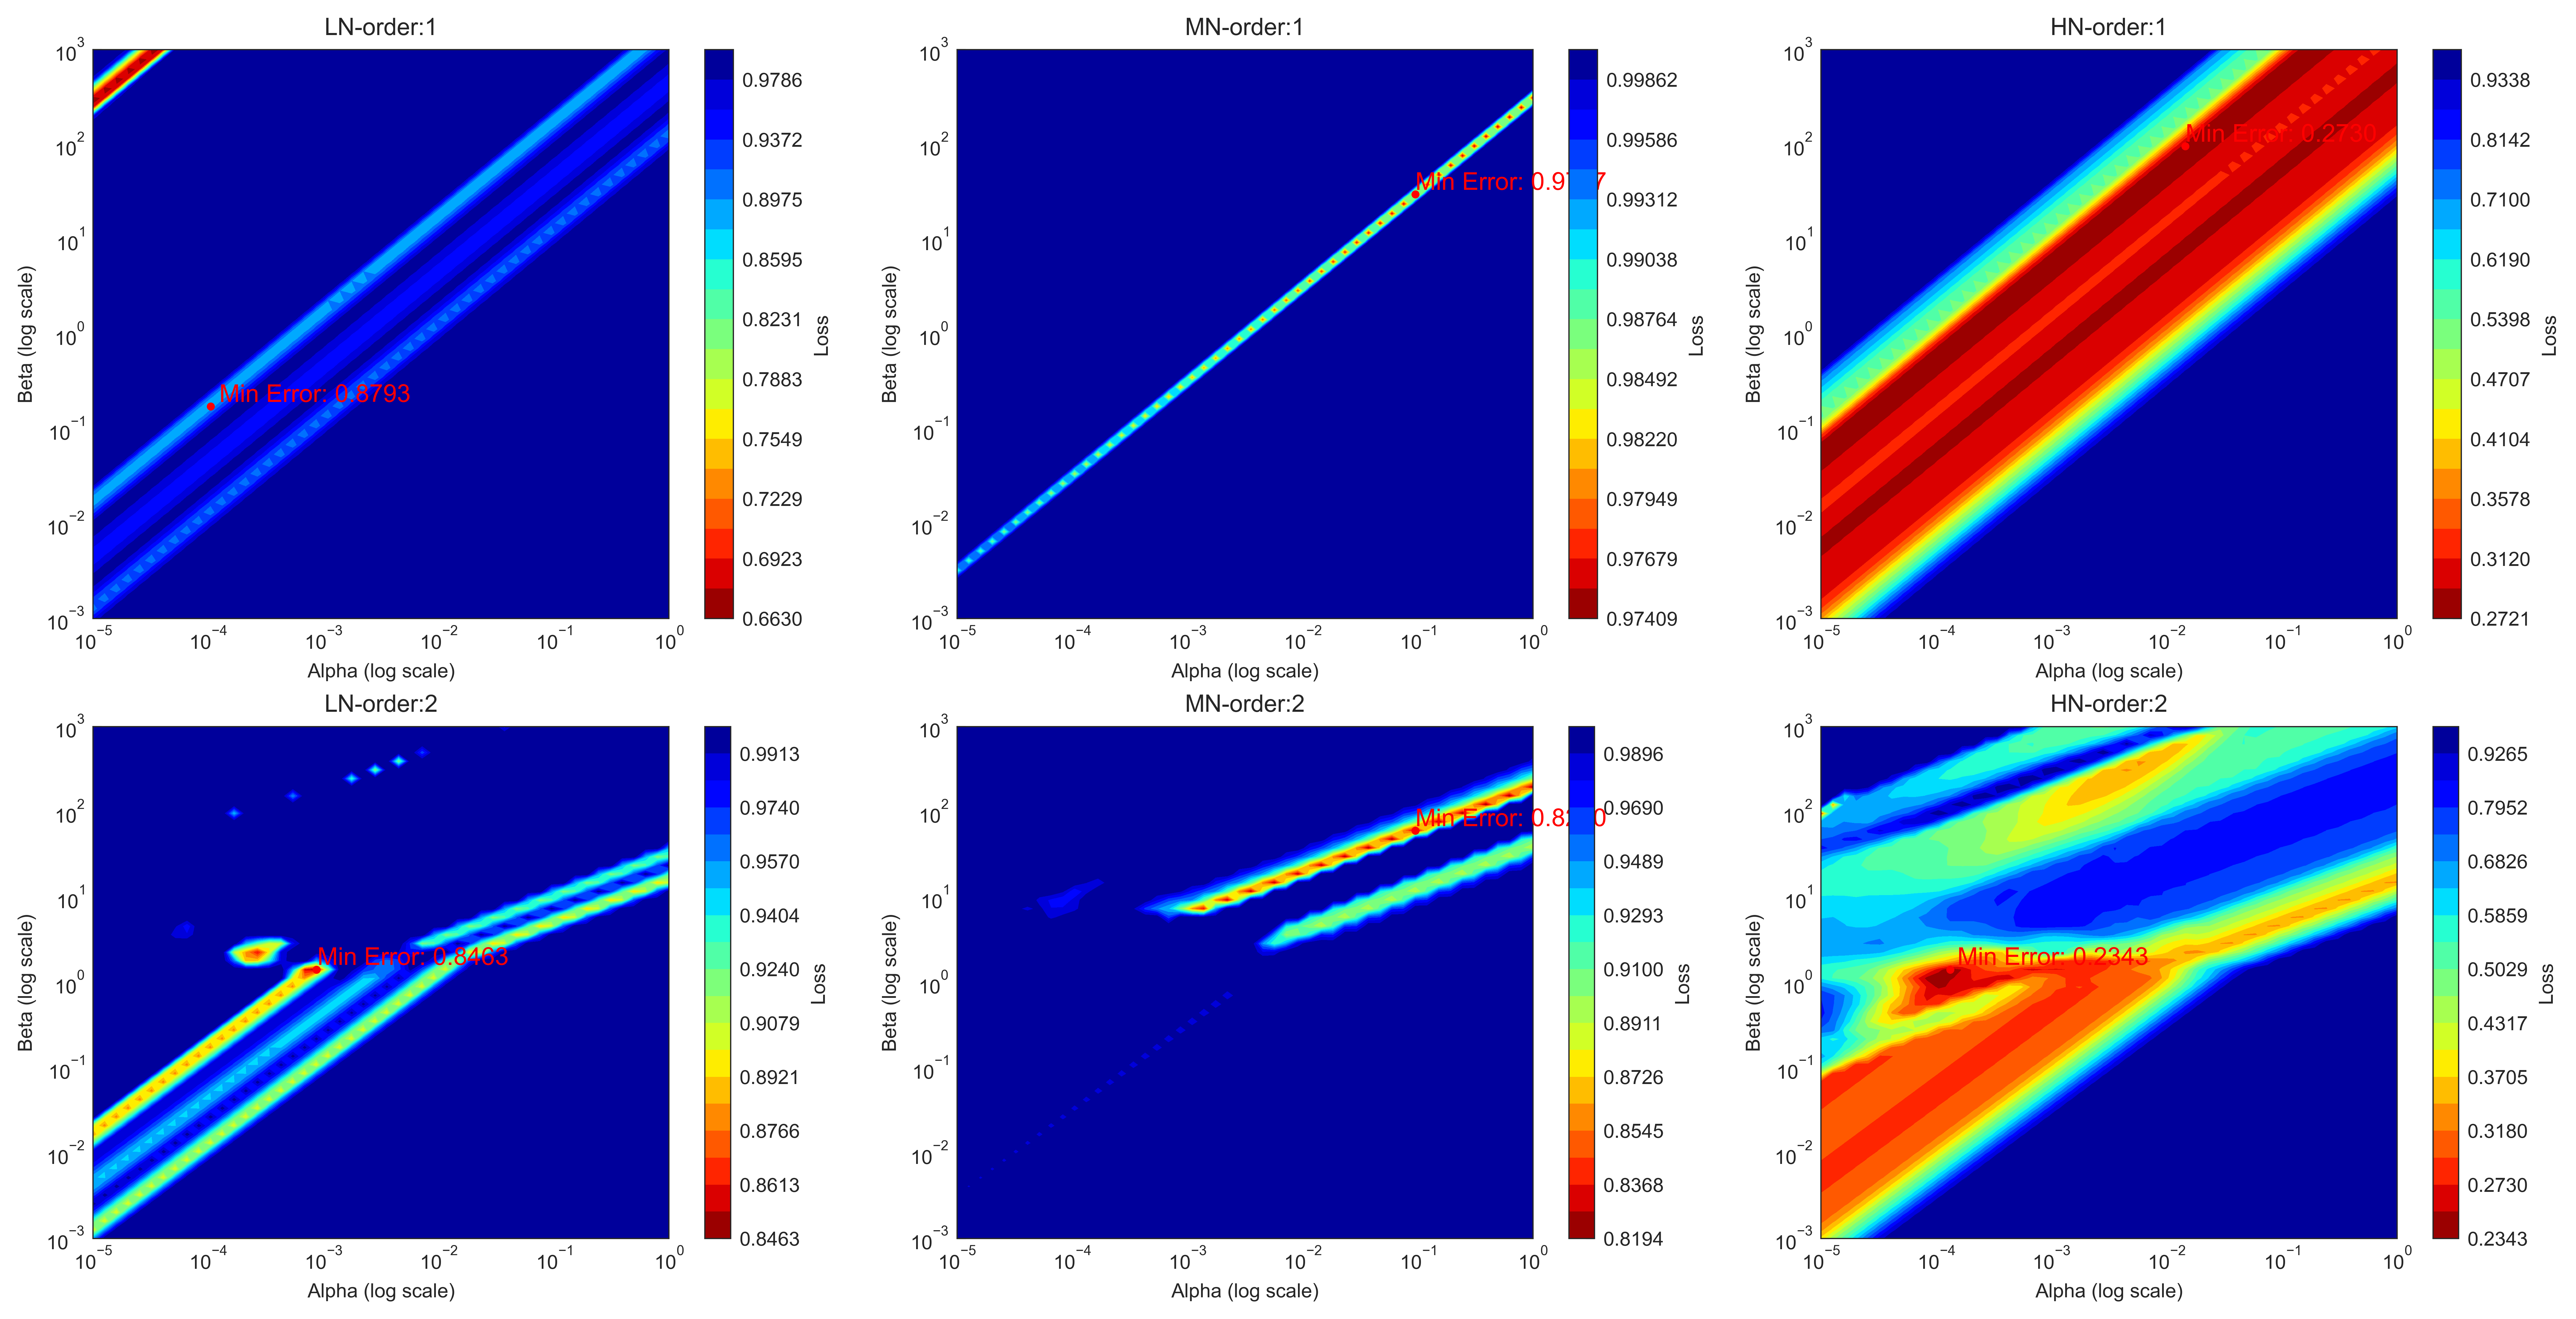

In [ ]:
mediums=['L','M','H']
orders=[1,2]
alphas=np.logspace(-5, -0, num=50)
betas=np.logspace(-3, 3, num=60)

fig=plt.figure(figsize=(450*mm,220*mm))
gs = GridSpec(2, 3, width_ratios=[1,1,1], height_ratios=[1,0.9])
    
for ii, medium in enumerate(mediums):
    for jj, order in enumerate(orders):
        filename=f'Partial_SpeciesNum_12_Medium_{medium}_Order_{order}_Preprocess_Normalize_mean_test_mse'
        with open('Data/'+filename+'.pkl', 'rb') as f:
            loaded_results = pickle.load(f)

        # Create a grid of alpha and beta values
        alpha_grid, beta_grid = np.meshgrid(alphas, betas)

        loss_values=np.zeros([len(alphas), len(betas)])

        for i, alpha in enumerate(alphas):
            for j, beta in enumerate(betas):
                loss_values[i,j]=loaded_results[(alpha,beta)]


        centered_offset=10
        loss_values_centered=loss_values[centered_offset:-centered_offset,centered_offset:-centered_offset]
        min_indices = np.unravel_index(np.argmin(loss_values_centered), loss_values_centered.shape)
        global_min_alpha = alphas[centered_offset+min_indices[0]]
        global_min_beta = betas[centered_offset+min_indices[1]]
        global_min_loss = loss_values_centered[min_indices]

        print(f'Min error condtion for {medium} and {order} is {global_min_alpha,global_min_beta}, error : {global_min_loss}')

        levels = np.logspace(np.log10(np.min(loss_values)), 0, 20)
        ax = fig.add_subplot(gs[jj, ii])
        # Create a contour plot
        contour = ax.contourf(alpha_grid, beta_grid, np.minimum(loss_values.T,1), levels=levels, cmap='jet_r', norm=LogNorm())
        ax.scatter(global_min_alpha, global_min_beta, color='red', marker='.', s=20)
        ax.text(global_min_alpha+2e-5, global_min_beta+2e-5, f'Min Error: {global_min_loss:.4f}', color='red', fontsize=10, ha='left', va='bottom')

        plt.colorbar(contour, label='Loss')
        plt.xscale('log')  # Set x-axis to log scale
        plt.yscale('log')  # Set y-axis to log scale
        plt.xlabel('Alpha (log scale)')
        plt.ylabel('Beta (log scale)')
        plt.title(f'{medium}N-order:{order}')
        plt.grid(True)
plt.savefig('Figure/Fig_5-1_LinearRegression_hyperparamterSearch.svg', bbox_inches='tight')
plt.show()


[-0.8405328258975614, 0.6941924214712825] [-0.8405328258975614, 0.6941924214712825]
0.2716684465487391


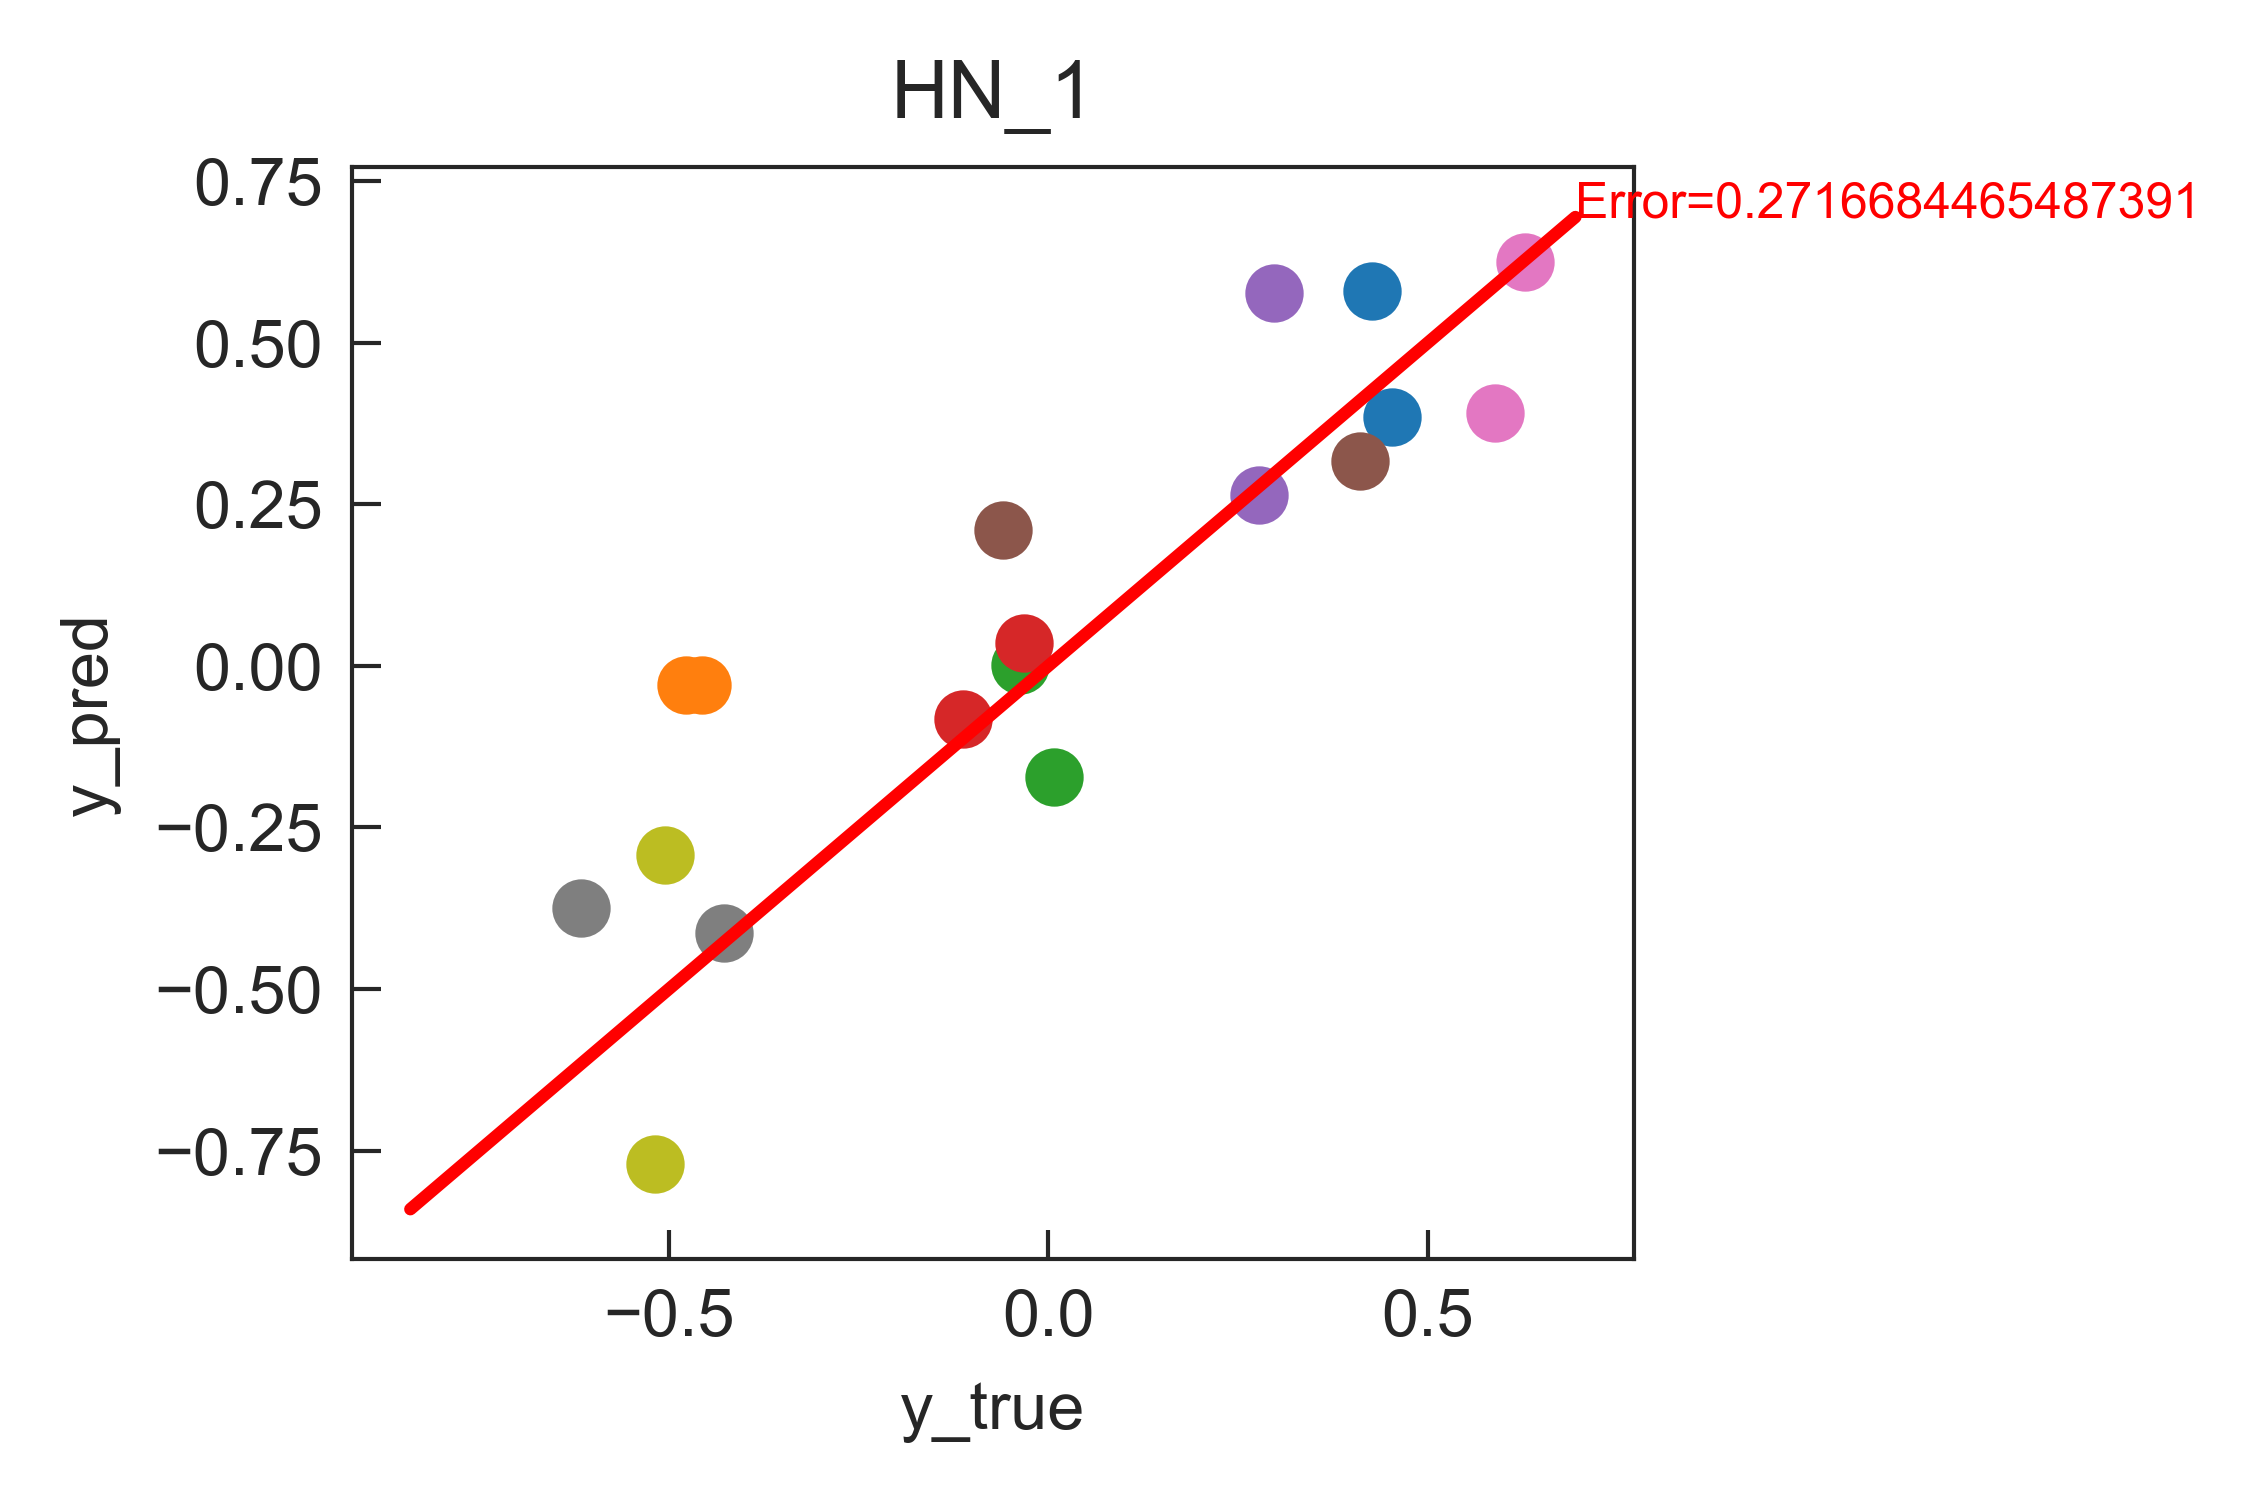

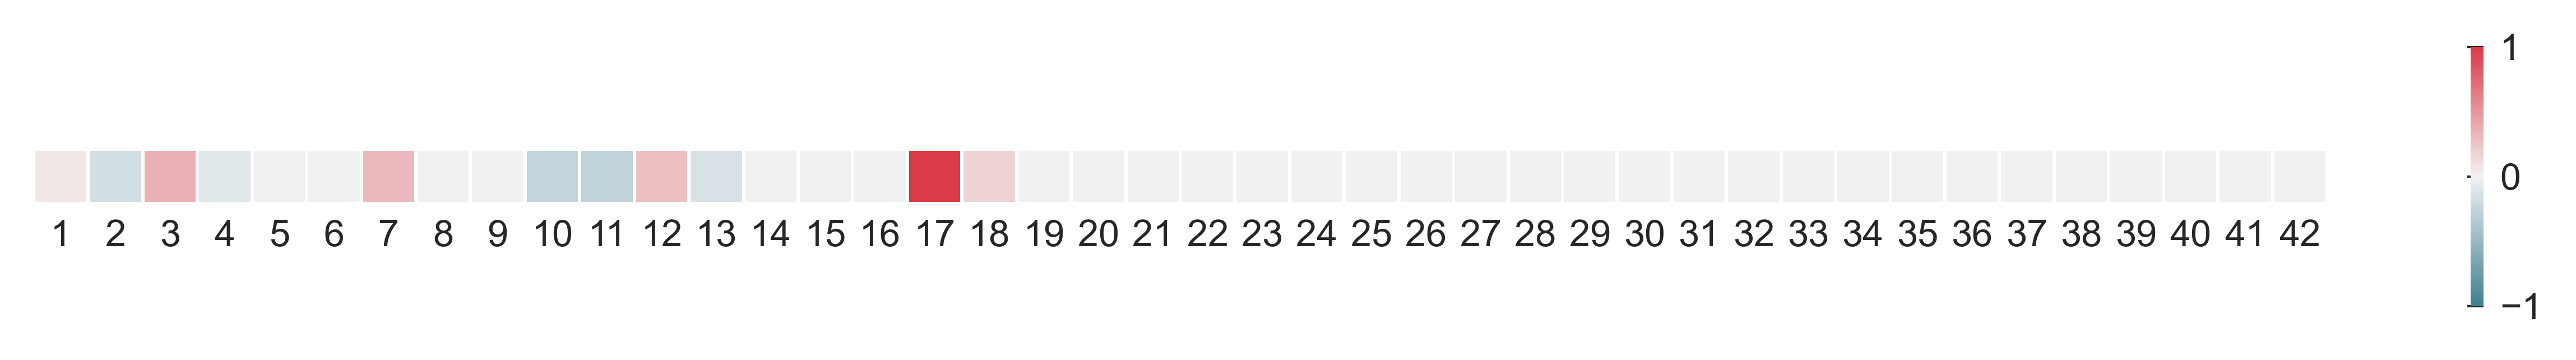

In [ ]:
Condition='HN_1'

if Condition== 'LN_1':
    medium="L"
    species_num=12
    com_type="S"
    rep=-1
    order=1
    #alpha = 2.559547922699533e-05
    #beta = 791.2342618981327
    alpha =0.00010481131341546853
    beta = 0.1726983290659436       
elif Condition == 'LN_2':
    medium="L"
    species_num=12
    com_type="S"
    rep=-1
    order=2
    alpha =0.000868511373751353
    beta = 1.4208308325339223
elif Condition == 'MN_1':
    medium="M"
    species_num=12
    com_type="S"
    rep=-1
    order=1
    alpha = 0.7906043210907702
    beta = 245.37511066398218
elif Condition =='MN_2':
    medium="M"
    species_num=12
    com_type="S"
    rep=-1
    order=2
    alpha = 0.09540954763499944
    beta=  60.20894493336138
elif Condition == 'HN_1':
    medium="H"
    species_num=12
    com_type="S"
    rep=-1
    order=1
    alpha = 0.1206792640639329
    beta= 791.2342618981327
elif Condition == 'HN_2':
    medium="H"
    species_num=12
    com_type="S"
    rep=-1
    order=2
    alpha = 0.00013257113655901095
    beta= 1.4208308325339223

# Set Hyper parameter Variable
preprocess='Normalize' ##'Basic', 'Normalize', 'ArcTanh'


##
Sub_IDX_list=Community_PermutateList("F", com_type, medium, "S", species_num, rep)
Coal_IDX_list=Community_PermutateList("F", com_type, medium, "C", species_num, rep)

matrix=getDominanceMatrix(Variable2plot, Coalescence_data, Coal_IDX_list, Sub_IDX_list)
df = pd.DataFrame(matrix)
df_sorted=df.sort_index(axis=1)
df_sorted=df_sorted.sort_index(axis=0)
competitive_scores = [1-np.mean(df.loc[row_col,:]) for row_col in df_sorted.index]

# Sort rows and columns by competitive score
sorted_idx = np.argsort(competitive_scores)[::-1]
df_sorted = df_sorted.iloc[sorted_idx, sorted_idx]
competitive_scores_sorted = [1-np.mean(df_sorted.loc[row_col,:]) for row_col in df_sorted.index]
competitive_scores_sorted

#getAbundance(getIDX(Processed_sequences_synthetic, IDX))
IDX_list=df_sorted.keys()
x=np.array(getAbundance_fromList(Processed_sequences_synthetic,df_sorted.keys()))
y=np.array(competitive_scores_sorted)


communityIDX_list, train_mse_list, test_mse_list, model, PF  = EstimateErrorLassoRegression(IDX_list, x, y, order=order, alpha=alpha, beta=beta, preprocess=preprocess)        
print(np.mean(test_mse_list))
plt.title(Condition)
plt.ylabel('y_pred')
plt.xlabel('y_true')
plt.savefig('Figure/Fig_5-1_LinearRegression_test_vs_predicted_'+Condition+'.svg', bbox_inches='tight')


if order==1:
    M0=model.coef_[0]
    M1=model.coef_[1:43]*1
    plotM1(M1,Condition=Condition)

elif order==2:
    M0=model.coef_[0]
    M1=model.coef_[1:43]
    M2=model.coef_[43:]

    plotM1(M1,Condition=Condition)
    plotM2(M2,Condition=Condition)
    

In [ ]:
M1

array([ 0.00016675, -0.00050392,  0.00101679, -0.0002529 , -0.        ,
       -0.        ,  0.00088354, -0.        , -0.        , -0.0007254 ,
       -0.00076655,  0.00076974, -0.00038865, -0.        ,  0.        ,
        0.        ,  0.00284317,  0.00048216,  0.        ,  0.        ,
        0.        ,  0.        , -0.        ,  0.        , -0.        ,
        0.        , -0.        ,  0.        , -0.        ,  0.        ,
        0.        ,  0.        , -0.        ,  0.        ,  0.        ,
       -0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ])

In [ ]:
def plotM1(M1,v_range=[-1,1],Condition='test'):
# Fill the upper triangle of the matrix, including the diagonal
    N=42
    # Create an empty N by N matrix
    data= np.zeros((N,1))

    for i in range(N):
        data[i] = M1[i]

    max_data=np.max(np.abs(data))
    data=data/max_data
    # Set up the matplotlib figure
    f, ax = plt.subplots(figsize=(11, 2))

    # Generate a custom diverging colormap
    cmap = sns.diverging_palette(220, 10, as_cmap=True)

    # Draw the heatmap with the mask and correct aspect ratio
    sns_plot = sns.heatmap(data.T, cmap=cmap, vmin=v_range[0], vmax=v_range[1], center=0,
                square=True, linewidths=.5, cbar_kws={"shrink": .5}, xticklabels=np.arange(1,N+1), yticklabels=[])
    # save to file
    fig = sns_plot.get_figure()
    fig.savefig('Figure/Fig_5-1_LinearRegression_theta_order1_'+Condition+'.svg', bbox_inches='tight')

    
def plotM2(M2,v_range=[-1,1],Condition='test'):
# Fill the upper triangle of the matrix, including the diagonal
    N=42
    # Create an empty N by N matrix
    data= np.zeros((N, N))

    for i in range(N):
        for j in range(0, i):
            data[i, j] = M2[int(i*(i+1)/2)+j]
    max_data=np.max(np.abs(data))
    data=data/max_data
    mask = np.zeros_like(data, dtype=np.bool)
    mask[np.triu_indices_from(mask)] = True

    # Want diagonal elements as well
    mask[np.diag_indices_from(mask)] = False

    # Set up the matplotlib figure
    f, ax = plt.subplots(figsize=(11, 9))

    # Generate a custom diverging colormap
    cmap = sns.diverging_palette(220, 10, as_cmap=True)

    # Draw the heatmap with the mask and correct aspect ratio
    sns_plot = sns.heatmap(data, mask=mask, cmap=cmap, vmin=v_range[0], vmax=v_range[1], center=0,
                square=True, linewidths=.5, cbar_kws={"shrink": .5}, xticklabels=np.arange(1,43), yticklabels=np.arange(1,43))
    # save to file
    fig = sns_plot.get_figure()
    fig.savefig('Figure/Fig_5-1_LinearRegression_theta_order2_'+Condition+'.svg', bbox_inches='tight')


In [ ]:
order

1

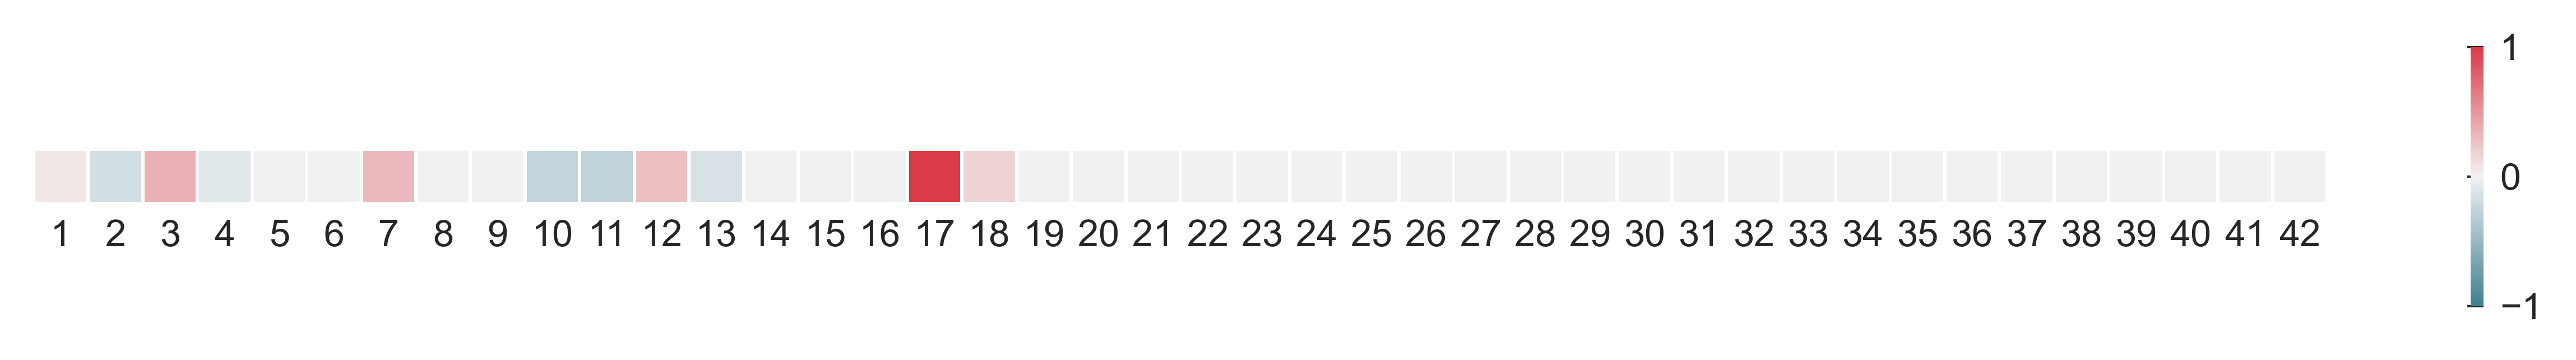

In [ ]:
if order==1:
    M0=model.coef_[0]
    M1=model.coef_[1:43]*300
    plotM1(M1)

elif order==2:
    M0=model.coef_[0]
    M1=model.coef_[1:43]
    M2=model.coef_[43:]*4000

    plotM1(M1)
    plotM2(M2)


In [ ]:
M1

In [ ]:

if order==1:
    M0=model.coef_[0]
    M1=model.coef_[1:43]*500
    plotM1(M1)

elif order==2:
    M0=model.coef_[0]
    M1=model.coef_[1:43]*2000000
    M2=model.coef_[43:]*20000

    plotM1(M1)
    plotM2(M2)


IndexError: index 42 is out of bounds for axis 0 with size 42

In [ ]:
def get_lower_tri_heatmap(df, output="cooc_matrix.png"):
    mask = np.zeros_like(df, dtype=np.bool)
    mask[np.triu_indices_from(mask)] = True

    # Want diagonal elements as well
    mask[np.diag_indices_from(mask)] = False

    # Set up the matplotlib figure
    f, ax = plt.subplots(figsize=(11, 9))

    # Generate a custom diverging colormap
    cmap = sns.diverging_palette(220, 10, as_cmap=True)

    # Draw the heatmap with the mask and correct aspect ratio
    sns_plot = sns.heatmap(data, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})
    # save to file
    fig = sns_plot.get_figure()
    fig.savefig(output)

In [ ]:
data[i,0]

In [10]:
df

,P2-38,P2-31,P2-39,P2-27,P2-45,P2-25,P2-29,P2-41,P2-40,P2-42,P2-33,P2-28,P2-30,P2-43,P2-26,P2-44,P2-32,P2-37
P2-44,0.778413,NaN,0.930974,NaN,NaN,NaN,NaN,NaN,0.957152,0.521900,NaN,NaN,NaN,0.746790,NaN,0.500000,NaN,0.559486
P2-39,0.210249,NaN,0.500000,NaN,0.008746,NaN,NaN,0.756330,NaN,NaN,NaN,NaN,NaN,0.985526,NaN,0.069026,NaN,0.945352
P2-41,0.026430,NaN,0.243670,NaN,0.054458,NaN,NaN,0.500000,0.032520,NaN,NaN,NaN,NaN,0.893290,NaN,NaN,NaN,0.777407
P2-43,0.003595,NaN,0.014474,NaN,NaN,NaN,NaN,0.106710,0.426504,0.135083,NaN,NaN,NaN,0.500000,NaN,0.253210,NaN,NaN
P2-45,0.112357,NaN,0.991254,NaN,0.500000,NaN,NaN,0.945542,0.996125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.969240
P2-38,0.500000,NaN,0.789751,NaN,0.887643,NaN,NaN,0.973570,NaN,NaN,NaN,NaN,NaN,0.996405,NaN,0.221587,NaN,NaN
P2-30,NaN,0.789687,NaN,NaN,NaN,0.552188,NaN,NaN,NaN,NaN,0.109436,0.105843,0.500000,NaN,0.003136,NaN,0.004337,NaN
P2-29,NaN,0.824002,NaN,0.061829,NaN,0.796370,0.500000,NaN,NaN,NaN,0.118888,0.151167,NaN,NaN,0.006029,NaN,NaN,NaN
P2-28,NaN,0.713205,NaN,NaN,NaN,0.778429,0.848833,NaN,NaN,NaN,0.120659,0.500000,0.894157,NaN,NaN,NaN,0.039983,NaN
P2-26,NaN,1.000000,NaN,0.848252,NaN,NaN,0.993971,NaN,NaN,NaN,0.572566,NaN,0.996864,NaN,0.500000,NaN,0.257199,NaN


AttributeError: 'DataFrame' object has no attribute 'iteritems'

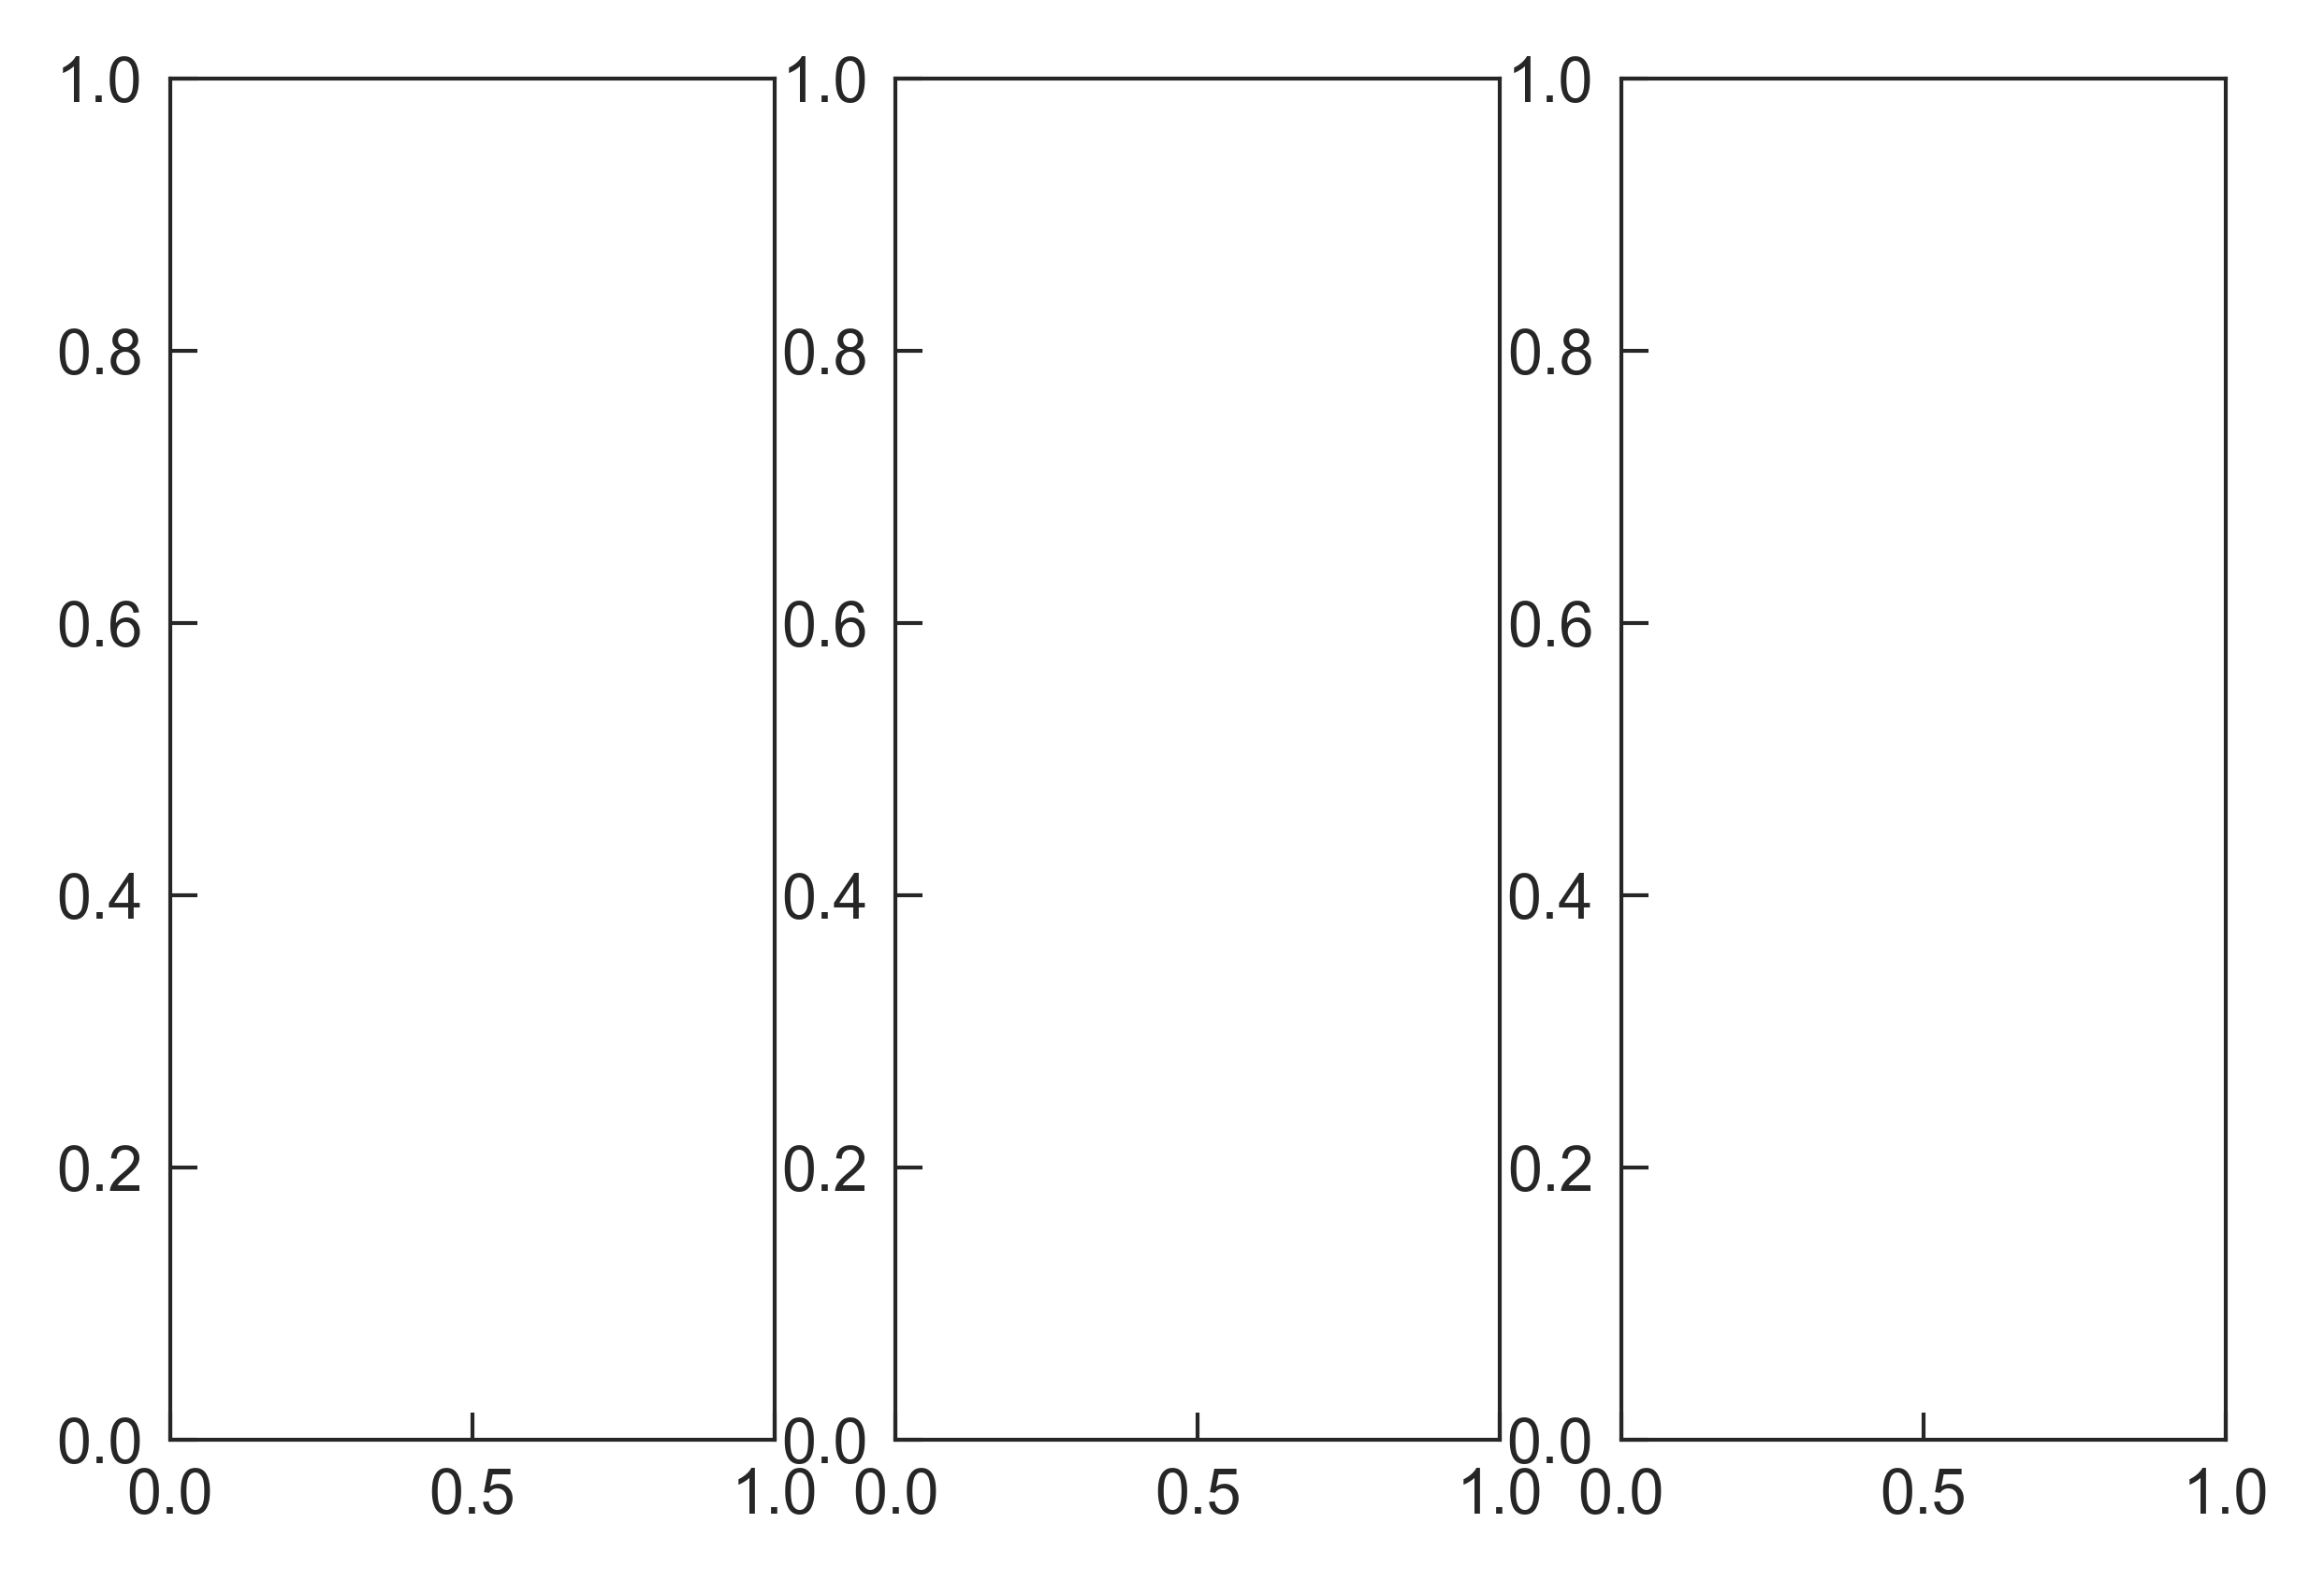

In [11]:
# Define your data
mediums = ['LN', 'MN', 'HN']
orders = ['Order 1', 'Order 2']  # Renamed from "states"

fig, axes = plt.subplots(1, 3, sharex=True, figsize=(120*mm,80*mm))

# Sample data (replace with your actual data)
data = 1-np.array([
0.8793, 0.8463,0.9747,0.8209,0.2730,0.2343
])
data=data.reshape(3,2)



colors=[sns.color_palette("tab10")[2], sns.color_palette("tab10")[0], sns.color_palette("tab10")[3]]

for i,ax in enumerate(axes):
    df=pd.DataFrame({'Order 1': [data[i,0]],'Order 2': [data[i,1]]})
    sns.barplot(ax=ax, data=df, width=0.7, color=colors[i])

    # Add labels and titles
    ax.set_xlabel(mediums[i])
    #ax.set_ticks(rotation=45)
    if i==0:
        ax.set_ylabel('R2 explained')
    ax.set_ylim([0,1])
    #axes[i].title('Grouped Barplot for Conditions and Orders')
    
    for j, val in enumerate(data[i, :]):
        ax.text(j, val, f'{val:.3f}', ha='center', va='bottom')

    # Show the legend
    #axes[i].legend(title='Orders')

    # Adjust the gap between bars of different orders
      # Rotate x-axis labels for better visibility

    #plt.show()
    
plt.show()
fig.savefig('Figure/Fig_5-1_LinearRegression_Error_barplot.svg', bbox_inches='tight')



In [ ]:
## Coal Figure 2. Plot every variable - swarm&box

typeofplot='swarmpoint' # choose among 'swarmbox', 'swarmpoint'
Variable2plot_list=[
       'Assymetricity_BC_5']


for Variable2plot in Variable2plot_list:
    data1=[0.121]
    
    data2=[0.025]
    
    data3 = [0.727]

    
    combined_data = np.concatenate([data1, data2, data3])
    labels = ['LN'] * len(data1) + ['MN'] * len(data2) + ['HN'] * len(data3)
    df = pd.DataFrame({'Value': combined_data, 'Data': labels})

    # Convert the data into a DataFrame
    f, ax = plt.subplots(1, figsize=(50*mm,50*mm),facecolor='w', edgecolor='k')
    #sns.boxplot(x='Data', y='Value', data=df, order=['LN', 'MN', 'HN'], width=0.2, boxprops=dict(alpha=.7),  linewidth=.5, palette = {"LN": sns.color_palette("tab10")[2], "MN": sns.color_palette("tab10")[0], "HN": sns.color_palette("tab10")[3]})
    sns.barplot(x='Data', y='Value', data=df,  errorbar=('se'), order=['LN', 'MN', 'HN'], width=0.5, alpha=0.7, capsize=.1, errwidth=1,  linewidth=.5, palette = {"LN": sns.color_palette("tab10")[2], "MN": sns.color_palette("tab10")[0], "HN": sns.color_palette("tab10")[3]})
    plt.ylabel('R2 explained')
    plt.ylim(0, 1.0)
    
    plt.legend()
    plt.show()
    f.savefig('Figure/Fig_5-1_NutrientVarying_BOXplot_R2Expalined.svg', bbox_inches='tight')

    
    
    


#AllAbudnaces=getAbundance(Metadata['SampleIDX'])